In [1]:
# packages
import pandas as pd
import numpy as np
np.random.seed(123)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
from patsy import dmatrix

plt.style.use("default") 

/Users/haiyuanyu/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
#read data from msk-chord data directory
sample_url = "https://media.githubusercontent.com/media/cBioPortal/datahub/refs/heads/master/public/msk_chord_2024/data_clinical_sample.txt"
patient_url = "https://media.githubusercontent.com/media/cBioPortal/datahub/refs/heads/master/public/msk_chord_2024/data_clinical_patient.txt"

sample_df = pd.read_csv(sample_url, sep="\t", comment="#")
patient_df = pd.read_csv(patient_url, sep="\t", comment="#")

print("Sample data shape:", sample_df.shape)
print("Patient data shape:", patient_df.shape)


Sample data shape: (25040, 24)
Patient data shape: (24950, 26)


In [3]:
#merge 
df = sample_df.merge(
    patient_df,
    on="PATIENT_ID",
    how="left",
    suffixes=("_sample", "_patient")
)

print("Merged data shape:", df.shape)
print(df.columns.tolist())

Merged data shape: (25040, 49)
['SAMPLE_ID', 'PATIENT_ID', 'GLEASON_SAMPLE_LEVEL', 'PDL1_POSITIVE', 'CANCER_TYPE', 'SAMPLE_TYPE', 'SAMPLE_CLASS', 'METASTATIC_SITE', 'PRIMARY_SITE', 'CANCER_TYPE_DETAILED', 'GENE_PANEL', 'SAMPLE_COVERAGE', 'TUMOR_PURITY', 'ONCOTREE_CODE', 'MSI_COMMENT', 'MSI_SCORE', 'MSI_TYPE', 'SOMATIC_STATUS', 'CLINICAL_GROUP', 'PATHOLOGICAL_GROUP', 'CLINICAL_SUMMARY', 'ICD_O_HISTOLOGY_DESCRIPTION', 'DIAGNOSIS_DESCRIPTION', 'TMB_NONSYNONYMOUS', 'GENDER', 'RACE', 'ETHNICITY', 'CURRENT_AGE_DEID', 'STAGE_HIGHEST_RECORDED', 'NUM_ICDO_DX', 'ADRENAL_GLANDS', 'BONE', 'CNS_BRAIN', 'INTRA_ABDOMINAL', 'LIVER', 'LUNG', 'LYMPH_NODES', 'OTHER', 'PLEURA', 'REPRODUCTIVE_ORGANS', 'SMOKING_PREDICTIONS_3_CLASSES', 'GLEASON_FIRST_REPORTED', 'GLEASON_HIGHEST_REPORTED', 'HISTORY_OF_PDL1', 'PRIOR_MED_TO_MSK', 'OS_MONTHS', 'OS_STATUS', 'HR', 'HER2']


In [4]:
#rebuild my own dataset (slicing the needed columns)


# Key columns based on merged MSK-CHORD DataHub files
cancer_col = "CANCER_TYPE"
os_months_col = "OS_MONTHS"
os_status_col = "OS_STATUS"
tmb_col = "TMB_NONSYNONYMOUS"
age_col = "CURRENT_AGE_DEID"
sex_col = "GENDER"
race_col = "RACE"
stage_col = "STAGE_HIGHEST_RECORDED"
msi_col = "MSI_TYPE"
purity_col = "TUMOR_PURITY"

df_crc = df[
    df[cancer_col].astype(str).str.contains("Colorectal Cancer", case=False, na=False)
].copy()

print("CRC cohort size:", df_crc.shape)
print(df_crc["CANCER_TYPE"].value_counts(dropna=False))


CRC cohort size: (5543, 49)
CANCER_TYPE
Colorectal Cancer    5543
Name: count, dtype: int64


In [5]:
#build outcome
df_crc["OS_months"] = pd.to_numeric(
    df_crc["OS_MONTHS"],
    errors="coerce"
)


#event 
df_crc["event"] = df_crc["OS_STATUS"].astype(str).apply(
    lambda x: 1 if "DECEASED" in x else 0
)


#exposure tmb
df_crc["TMB"] = pd.to_numeric(
    df_crc["TMB_NONSYNONYMOUS"],
    errors="coerce"
)


#clinical tmb group
df_crc["TMB_group"] = np.where(
    df_crc["TMB"] >= 10,
    "High TMB (≥10 mut/Mb)",
    "Low TMB (<10 mut/Mb)"
)

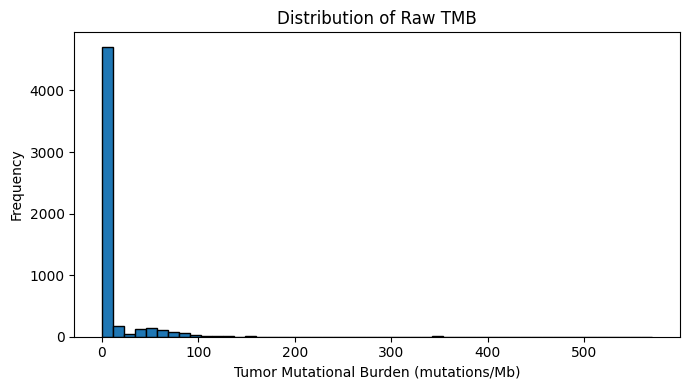

In [6]:
plt.figure(figsize=(7, 4))

plt.hist(df_crc["TMB"], bins=50, edgecolor="black")

plt.title("Distribution of Raw TMB")
plt.xlabel("Tumor Mutational Burden (mutations/Mb)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

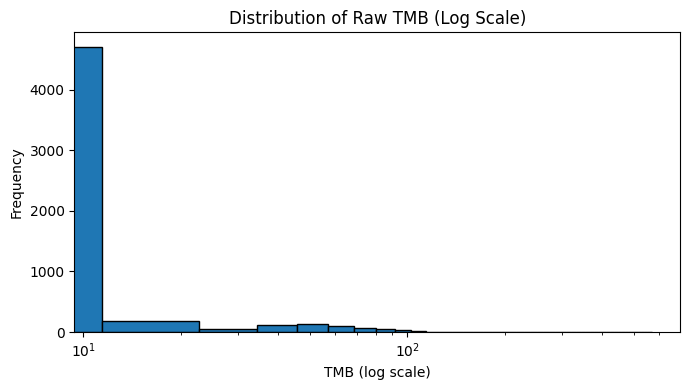

In [7]:
plt.figure(figsize=(7,4))

plt.hist(df_crc["TMB"], bins=50, edgecolor="black")
plt.xscale("log")   

plt.title("Distribution of Raw TMB (Log Scale)")
plt.xlabel("TMB (log scale)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [8]:
#log-transformed tmb forcox model
df_crc["log_TMB"] = np.log1p(df_crc["TMB"])


#covariates

#age
df_crc["age"] = pd.to_numeric(
    df_crc["CURRENT_AGE_DEID"],
    errors="coerce"
)

#sex
df_crc["sex"] = df_crc["GENDER"]


#cleaning race 
df_crc["Race_clean"] = df_crc["RACE"].replace({
    "No Value Entered": pd.NA,
    "Unknown": pd.NA,
    "Pt Refused To Answer": pd.NA,
    "Not Available": pd.NA
})


#stage 1-3 vs 4
df_crc["stage4_bin"] = df_crc["STAGE_HIGHEST_RECORDED"].apply(
    lambda x: "Stage IV" if str(x) in ["Stage 4", "Stage IV", "4", "IV"] else "Stage I-III"
)


#tumor purity
df_crc["tumor_purity"] = pd.to_numeric(
    df_crc["TUMOR_PURITY"],
    errors="coerce"
)


#msi cleaning
df_crc["MSI_clean"] = df_crc["MSI_TYPE"].replace({
    "Unknown": pd.NA,
    "Not Available": pd.NA,
    "NA": pd.NA,
    "nan": pd.NA,
    "Indeterminate": pd.NA,
    "Do not report": pd.NA
})

In [9]:
print(df_crc[[
    "OS_months", "event", "TMB", "log_TMB",
    "age", "sex", "Race_clean", "stage4_bin",
    "tumor_purity", "MSI_clean"
]].isna().sum())

print("\nTMB groups:")
print(df_crc["TMB_group"].value_counts(dropna=False))

print("\nMSI categories:")
print(df_crc["MSI_clean"].value_counts(dropna=False))

print("\nStage groups:")
print(df_crc["stage4_bin"].value_counts(dropna=False))

OS_months         0
event             0
TMB               0
log_TMB           0
age               0
sex               0
Race_clean      189
stage4_bin        0
tumor_purity     82
MSI_clean       275
dtype: int64

TMB groups:
TMB_group
Low TMB (<10 mut/Mb)     4544
High TMB (≥10 mut/Mb)     999
Name: count, dtype: int64

MSI categories:
MSI_clean
Stable      4682
Instable     586
<NA>         237
NaN           38
Name: count, dtype: int64

Stage groups:
stage4_bin
Stage I-III    3171
Stage IV       2372
Name: count, dtype: int64


In [10]:
print(df_crc["MSI_TYPE"].value_counts(dropna=False))
df_crc["MSI_final"] = df_crc["MSI_clean"].replace({
    "Stable": "MSS",
    "Instable": "MSI-High",
    "Indeterminate": pd.NA,
    "Do not report": pd.NA
})


MSI_TYPE
Stable           4682
Instable          586
Indeterminate     188
Do not report      49
NaN                38
Name: count, dtype: int64


In [11]:
#build complete case dataset 
cox_df = df_crc[[
    "OS_months",
    "event",
    "TMB",
    "log_TMB",
    "TMB_group",
    "age",
    "sex",
    "Race_clean",
    "stage4_bin",
    "MSI_final",
    "tumor_purity"
]].dropna().copy()

#collapse small race categories for more stable modeling
cox_df["Race_model"] = cox_df["Race_clean"].replace({
    "Native American-Am Ind/Alaska": "Other",
    "Native Hawaiian Or Pacific Isl": "Other"
})

#age group and tmb quartile
bins = [0, 40, 50, 60, 70, 80, 100]
labels = ["<40", "40-50", "50-60", "60-70", "70-80", "80+"]

cox_df["age_group"] = pd.cut(
    cox_df["age"],
    bins=bins,
    labels=labels,
    right=False
)

cox_df["TMB_quartile"] = pd.qcut(
    cox_df["TMB"],
    4,
    labels=["Q1", "Q2", "Q3", "Q4"])





In [12]:
#check
print("Original CRC cohort:", df_crc.shape[0])
print("Analytic sample after dropna:", cox_df.shape[0])
print("Dropped:", df_crc.shape[0] - cox_df.shape[0])

print("\nMissing values in analytic dataset:")
print(cox_df.isna().sum())

print("\nTMB groups:")
print(cox_df["TMB_group"].value_counts())

print("\nMSI groups:")
print(cox_df["MSI_final"].value_counts())

print("\nStage groups:")
print(cox_df["stage4_bin"].value_counts())

print("\nRace groups:")
print(cox_df["Race_model"].value_counts())

print("\nEvent distribution:")
print(cox_df["event"].value_counts())

Original CRC cohort: 5543
Analytic sample after dropna: 5019
Dropped: 524

Missing values in analytic dataset:
OS_months       0
event           0
TMB             0
log_TMB         0
TMB_group       0
age             0
sex             0
Race_clean      0
stage4_bin      0
MSI_final       0
tumor_purity    0
Race_model      0
age_group       0
TMB_quartile    0
dtype: int64

TMB groups:
TMB_group
Low TMB (<10 mut/Mb)     4121
High TMB (≥10 mut/Mb)     898
Name: count, dtype: int64

MSI groups:
MSI_final
MSS         4456
MSI-High     563
Name: count, dtype: int64

Stage groups:
stage4_bin
Stage I-III    2887
Stage IV       2132
Name: count, dtype: int64

Race groups:
Race_model
White                            4043
Asian-Far East/Indian Subcont     436
Black Or African American         361
Other                             179
Name: count, dtype: int64

Event distribution:
event
0    3019
1    2000
Name: count, dtype: int64


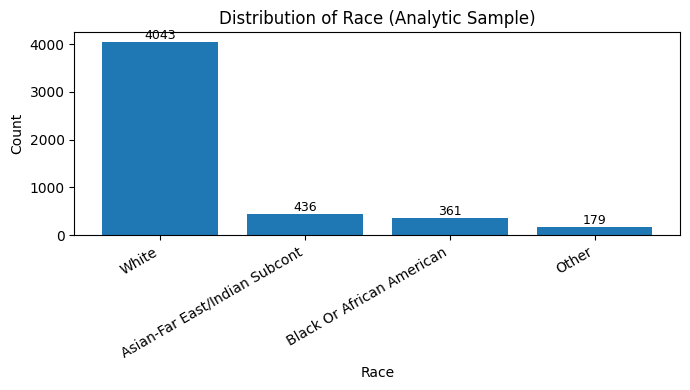

In [13]:
race_counts = cox_df["Race_model"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(7,4))

plt.bar(range(len(race_counts)), race_counts.values)

plt.xticks(
    range(len(race_counts)),
    race_counts.index,
    rotation=30,
    ha='right'
)

for i, v in enumerate(race_counts.values):
    plt.text(i, v, f"{v}", ha='center', va='bottom', fontsize=9)
    
plt.title("Distribution of Race (Analytic Sample)")
plt.xlabel("Race")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

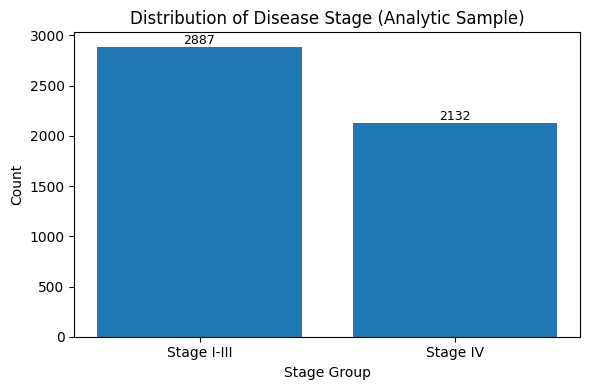

In [14]:
stage_counts = cox_df["stage4_bin"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(6,4))

plt.bar(range(len(stage_counts)), stage_counts.values)

plt.xticks(
    range(len(stage_counts)),
    stage_counts.index
)

plt.title("Distribution of Disease Stage (Analytic Sample)")
plt.xlabel("Stage Group")
plt.ylabel("Count")


for i, v in enumerate(stage_counts.values):
    plt.text(i, v, f"{v}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

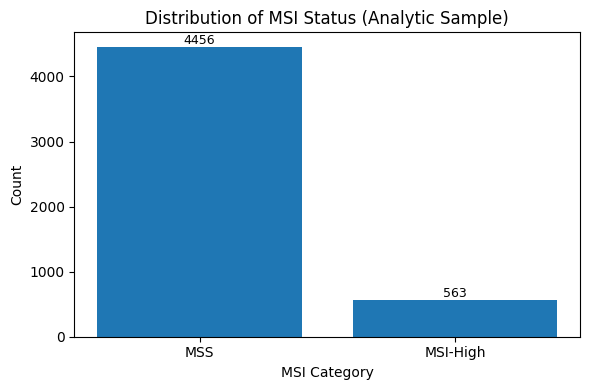

In [15]:
msi_counts = cox_df["MSI_final"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(6,4))

plt.bar(range(len(msi_counts)), msi_counts.values)

plt.xticks(
    range(len(msi_counts)),
    msi_counts.index
)

plt.title("Distribution of MSI Status (Analytic Sample)")
plt.xlabel("MSI Category")
plt.ylabel("Count")

for i, v in enumerate(msi_counts.values):
    plt.text(i, v, f"{v}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

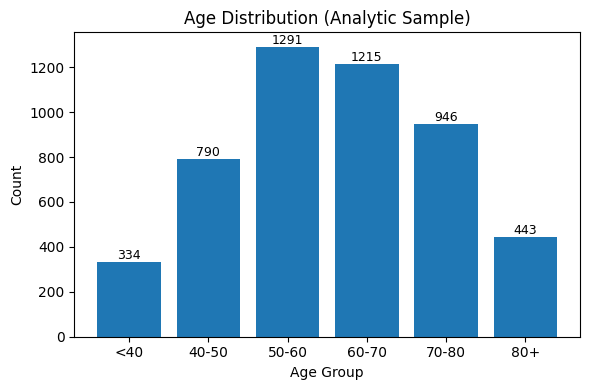

In [16]:
age_counts = cox_df["age_group"].value_counts().sort_index()

plt.figure(figsize=(6,4))

plt.bar(range(len(age_counts)), age_counts.values)

plt.xticks(
    range(len(age_counts)),
    age_counts.index
)

plt.title("Age Distribution (Analytic Sample)")
plt.xlabel("Age Group")
plt.ylabel("Count")


for i, v in enumerate(age_counts.values):
    plt.text(i, v, f"{v}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [17]:
#counts
ct_counts = pd.crosstab(
    cox_df["event"],
    cox_df["stage4_bin"]
)

print("Counts (Event x Stage):")
print(ct_counts)

#raw percent
ct_prop = pd.crosstab(
    cox_df["event"],
    cox_df["stage4_bin"],
    normalize="index"
).round(3)

print("\nRow proportions:")
print(ct_prop)

Counts (Event x Stage):
stage4_bin  Stage I-III  Stage IV
event                            
0                  2184       835
1                   703      1297

Row proportions:
stage4_bin  Stage I-III  Stage IV
event                            
0                 0.723     0.277
1                 0.352     0.648


In [18]:
#tmb groups
tmb_counts = cox_df["TMB_group"].value_counts()
print("TMB group distribution:")
print(tmb_counts)

print("\nPreview:")
print(cox_df[["TMB", "TMB_group"]].head())


#log-rank test comparing tmb groups
low_tmb = cox_df[cox_df["TMB_group"] == "Low TMB (<10 mut/Mb)"]
high_tmb = cox_df[cox_df["TMB_group"] == "High TMB (≥10 mut/Mb)"]

logrank_res = logrank_test(
    low_tmb["OS_months"],
    high_tmb["OS_months"],
    event_observed_A=low_tmb["event"],
    event_observed_B=high_tmb["event"]
)

print("\nLog-rank test:")
print(f"p-value = {logrank_res.p_value:.3e}")

TMB group distribution:
TMB_group
Low TMB (<10 mut/Mb)     4121
High TMB (≥10 mut/Mb)     898
Name: count, dtype: int64

Preview:
          TMB             TMB_group
22   8.873242  Low TMB (<10 mut/Mb)
30   9.982398  Low TMB (<10 mut/Mb)
150  6.654932  Low TMB (<10 mut/Mb)
154  5.545777  Low TMB (<10 mut/Mb)
166  8.873242  Low TMB (<10 mut/Mb)

Log-rank test:
p-value = 6.990e-14


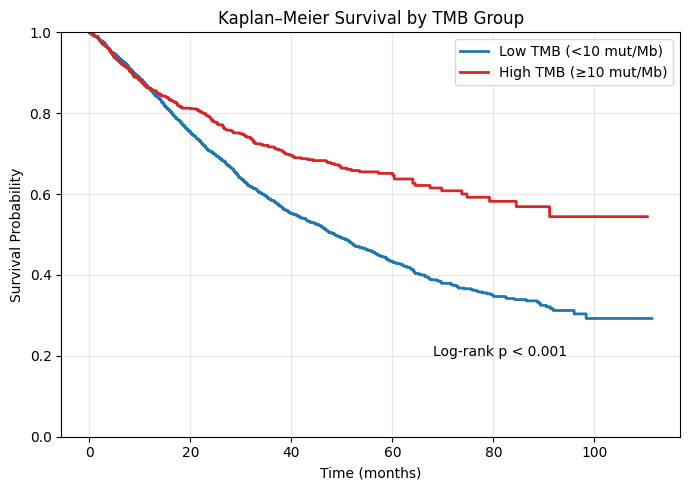

In [19]:
# km curve 

kmf = KaplanMeierFitter()

plt.figure(figsize=(7,5))

groups = [
    "Low TMB (<10 mut/Mb)",
    "High TMB (≥10 mut/Mb)"
]

colors = ["#1f77b4", "#d62728"]

for group, color in zip(groups, colors):
    mask = cox_df["TMB_group"] == group
    
    kmf.fit(
        durations=cox_df.loc[mask, "OS_months"],
        event_observed=cox_df.loc[mask, "event"],
        label=group
    )
    
    kmf.plot_survival_function(
        ci_show=False,
        linewidth=2,
        color=color
    )

#p-value
p = logrank_res.p_value
p_text = "p < 0.001" if p < 0.001 else f"p = {p:.3f}"

plt.text(
    0.6, 0.2,
    f"Log-rank {p_text}",
    transform=plt.gca().transAxes,
    fontsize=10
)

plt.title("Kaplan–Meier Survival by TMB Group")
plt.xlabel("Time (months)")
plt.ylabel("Survival Probability")

plt.ylim(0, 1)  

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
#stratified stage and msi km graphs
def plot_km_by_tmb(data, title):
    kmf = KaplanMeierFitter()

    groups = [
        "Low TMB (<10 mut/Mb)",
        "High TMB (≥10 mut/Mb)"
    ]
    colors = ["#1f77b4", "#d62728"]

    # log-rank test
    low_tmb = data[data["TMB_group"] == groups[0]]
    high_tmb = data[data["TMB_group"] == groups[1]]

    logrank_res = logrank_test(
        low_tmb["OS_months"],
        high_tmb["OS_months"],
        event_observed_A=low_tmb["event"],
        event_observed_B=high_tmb["event"]
    )

    p = logrank_res.p_value
    p_text = "p < 0.001" if p < 0.001 else f"p = {p:.3f}"

    plt.figure(figsize=(6,5))

    for group, color in zip(groups, colors):
        mask = data["TMB_group"] == group

        kmf.fit(
            durations=data.loc[mask, "OS_months"],
            event_observed=data.loc[mask, "event"],
            label=group
        )

        kmf.plot_survival_function(
            ci_show=False,
            linewidth=2,
            color=color
        )

    plt.text(
        0.58, 0.2,
        f"Log-rank {p_text}",
        transform=plt.gca().transAxes,
        fontsize=10
    )

    plt.title(title)
    plt.xlabel("Time (months)")
    plt.ylabel("Survival Probability")
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    



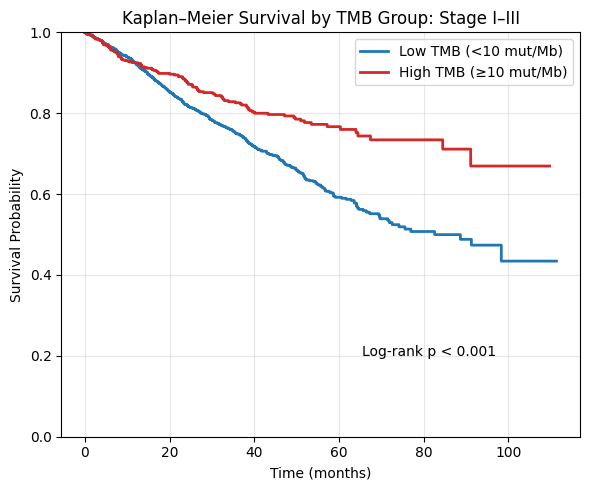

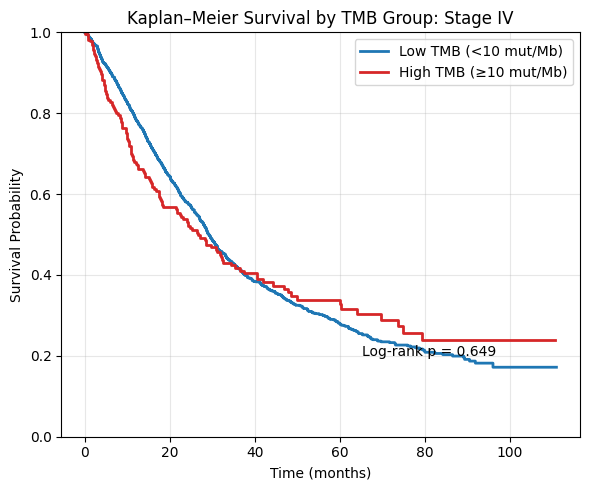

In [21]:
#stage stratified 
plot_km_by_tmb(
    cox_df[cox_df["stage4_bin"] == "Stage I-III"],
    "Kaplan–Meier Survival by TMB Group: Stage I–III"
)

plot_km_by_tmb(
    cox_df[cox_df["stage4_bin"] == "Stage IV"],
    "Kaplan–Meier Survival by TMB Group: Stage IV"
)

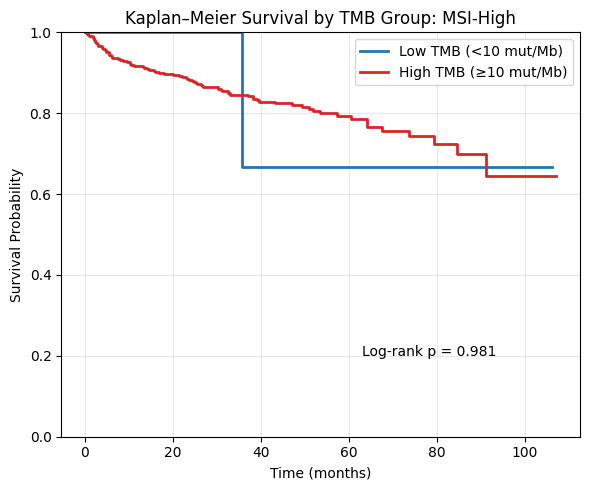

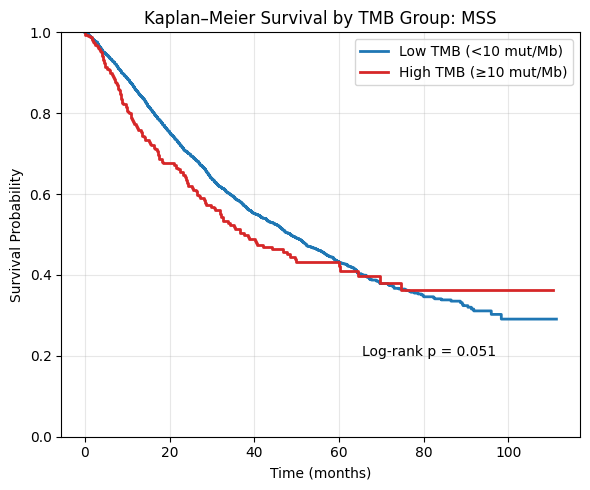

In [22]:
#msi stratified
plot_km_by_tmb(
    cox_df[cox_df["MSI_final"] == "MSI-High"],
    "Kaplan–Meier Survival by TMB Group: MSI-High"
)

plot_km_by_tmb(
    cox_df[cox_df["MSI_final"] == "MSS"],
    "Kaplan–Meier Survival by TMB Group: MSS"
)

In [23]:
#standard multivariable cox model log_TMB + age + sex + race + stage + MSI + tumor_purity
cox_model_df = cox_df[[
    "OS_months",
    "event",
    "log_TMB",
    "age",
    "tumor_purity",
    "sex",
    "Race_model",
    "stage4_bin",
    "MSI_final"
]].copy()

cox_model_df = pd.get_dummies(
    cox_model_df,
    columns=["sex", "Race_model", "stage4_bin", "MSI_final"],
    drop_first=True
)

cph_standard = CoxPHFitter()

cph_standard.fit(
    cox_model_df,
    duration_col="OS_months",
    event_col="event"
)

cph_standard.print_summary()

<lifelines.CoxPHFitter: fitted with 5019 total observations, 3019 right-censored observations>
             duration col = 'OS_months'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 5019
number of events observed = 2000
   partial log-likelihood = -15427.08
         time fit was run = 2026-04-28 01:18:15 UTC

---
                                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                             
log_TMB                               0.02      1.02      0.05           -0.06            0.11                0.94                1.12
age                                   0.00      1.00      0.00           -0.00            0.00                1.00                1.00
tumor_purity                          0.00      1.00      0.00           -0.00            0.00                1.00                1.00
sex_Male                              0.02      1.03      0.05           -0.06            0.11                0.94                1.12
Race_model_Black Or African American  0.45      1.56      0.11            0.23            0.66                1.25                1.94
Race_model_Other                      0.04      1.04      0.15           -0.25            0.34                0.78                1.40
Race_model_White                      0.09      1.10      0.09           -0.08            0.26                0.93                1.30
stage4_bin_Stage IV                   1.00      2.73      0.05            0.91            1.10                2.48                3.00
MSI_final_MSS                         0.79      2.20      0.14            0.50            1.07                1.65                2.92

                                      cmp to     z      p  -log2(p)
covariate                                                          
log_TMB                                 0.00  0.52   0.60      0.74
age                                     0.00  0.03   0.98      0.03
tumor_purity                            0.00  0.57   0.57      0.82
sex_Male                                0.00  0.55   0.58      0.79
Race_model_Black Or African American    0.00  3.98 <0.005     13.82
Race_model_Other                        0.00  0.29   0.77      0.37
Race_model_White                        0.00  1.08   0.28      1.84
stage4_bin_Stage IV                     0.00 20.91 <0.005    320.17
MSI_final_MSS                           0.00  5.44 <0.005     24.14
---
Concordance = 0.66
Partial AIC = 30872.16
log-likelihood ratio test = 647.32 on 9 df
-log2(p) of ll-ratio test = 441.28

In [24]:
#stratified cox model by stage
cox_strata_df = cox_df[[
    "OS_months",
    "event",
    "log_TMB",
    "age",
    "tumor_purity",
    "sex",
    "Race_model",
    "MSI_final",
    "stage4_bin"
]].copy()

cox_strata_df = pd.get_dummies(
    cox_strata_df,
    columns=["sex", "Race_model", "MSI_final"],
    drop_first=True
)

cph_strata_stage = CoxPHFitter()

cph_strata_stage.fit(
    cox_strata_df,
    duration_col="OS_months",
    event_col="event",
    strata=["stage4_bin"]
)

cph_strata_stage.print_summary()



<lifelines.CoxPHFitter: fitted with 5019 total observations, 3019 right-censored observations>
             duration col = 'OS_months'
                event col = 'event'
                   strata = stage4_bin
      baseline estimation = breslow
   number of observations = 5019
number of events observed = 2000
   partial log-likelihood = -14133.41
         time fit was run = 2026-04-28 01:18:15 UTC

---
                                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                             
log_TMB                               0.02      1.02      0.05           -0.07            0.11                0.94                1.12
age                                   0.00      1.00      0.00           -0.00            0.00                1.00                1.00
tumor_purity                          0.00      1.00      0.00           -0.00            0.00                1.00                1.00
sex_Male                              0.03      1.03      0.05           -0.06            0.11                0.94                1.12
Race_model_Black Or African American  0.44      1.55      0.11            0.22            0.66                1.24                1.93
Race_model_Other                      0.05      1.05      0.15           -0.24            0.35                0.78                1.41
Race_model_White                      0.09      1.10      0.09           -0.07            0.26                0.93                1.30
MSI_final_MSS                         0.80      2.22      0.14            0.51            1.08                1.67                2.94

                                      cmp to    z      p  -log2(p)
covariate                                                         
log_TMB                                 0.00 0.52   0.61      0.72
age                                     0.00 0.07   0.94      0.09
tumor_purity                            0.00 0.58   0.56      0.83
sex_Male                                0.00 0.59   0.56      0.85
Race_model_Black Or African American    0.00 3.91 <0.005     13.39
Race_model_Other                        0.00 0.34   0.73      0.45
Race_model_White                        0.00 1.08   0.28      1.85
MSI_final_MSS                           0.00 5.51 <0.005     24.71
---
Concordance = 0.55
Partial AIC = 28282.83
log-likelihood ratio test = 78.36 on 8 df
-log2(p) of ll-ratio test = 43.12

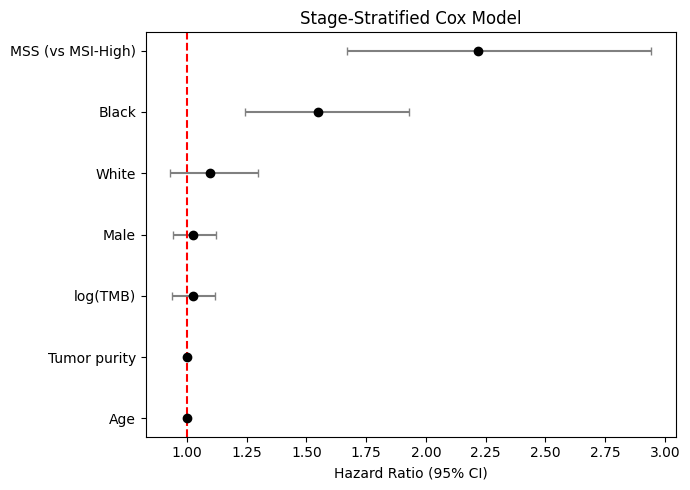

In [25]:
summary = cph_strata_stage.summary.copy()

summary["HR"] = summary["exp(coef)"]
summary["CI_lower"] = summary["exp(coef) lower 95%"]
summary["CI_upper"] = summary["exp(coef) upper 95%"]

summary = summary.reset_index()

if "covariate" in summary.columns:
    summary = summary.rename(columns={"covariate": "variable"})
else:
    summary = summary.rename(columns={"index": "variable"})

keep_vars = [
    "log_TMB",
    "age",
    "tumor_purity",
    "sex_Male",
    "Race_model_Black Or African American",
    "Race_model_White",
    "MSI_final_MSS"
]

summary = summary[summary["variable"].isin(keep_vars)].copy()
summary = summary.sort_values("HR")

label_map = {
    "log_TMB": "log(TMB)",
    "age": "Age",
    "tumor_purity": "Tumor purity",
    "sex_Male": "Male",
    "Race_model_Black Or African American": "Black",
    "Race_model_White": "White",
    "MSI_final_MSS": "MSS (vs MSI-High)"
}

summary["label"] = summary["variable"].map(label_map)

y_pos = np.arange(len(summary))

plt.figure(figsize=(7,5))

plt.errorbar(
    summary["HR"],
    y_pos,
    xerr=[
        summary["HR"] - summary["CI_lower"],
        summary["CI_upper"] - summary["HR"]
    ],
    fmt="o",
    color="black",
    ecolor="gray",
    capsize=3
)

plt.axvline(x=1, linestyle="--", color="red")

plt.yticks(y_pos, summary["label"])
plt.xlabel("Hazard Ratio (95% CI)")
plt.title("Stage-Stratified Cox Model")

plt.tight_layout()
plt.show()

In [26]:
#stratified cox model by msi
cox_strata_msi_df = cox_df[[
    "OS_months",
    "event",
    "log_TMB",
    "age",
    "tumor_purity",
    "sex",
    "Race_model",
    "stage4_bin",
    "MSI_final"
]].copy()

cox_strata_msi_df = pd.get_dummies(
    cox_strata_msi_df,
    columns=["sex", "Race_model", "stage4_bin"],
    drop_first=True
)

cph_strata_msi = CoxPHFitter()

cph_strata_msi.fit(
    cox_strata_msi_df,
    duration_col="OS_months",
    event_col="event",
    strata=["MSI_final"]
)

cph_strata_msi.print_summary()

<lifelines.CoxPHFitter: fitted with 5019 total observations, 3019 right-censored observations>
             duration col = 'OS_months'
                event col = 'event'
                   strata = MSI_final
      baseline estimation = breslow
   number of observations = 5019
number of events observed = 2000
   partial log-likelihood = -15045.18
         time fit was run = 2026-04-28 01:18:16 UTC

---
                                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                             
log_TMB                               0.03      1.03      0.05           -0.06            0.11                0.94                1.12
age                                   0.00      1.00      0.00           -0.00            0.00                1.00                1.00
tumor_purity                          0.00      1.00      0.00           -0.00            0.00                1.00                1.00
sex_Male                              0.03      1.03      0.05           -0.06            0.11                0.94                1.12
Race_model_Black Or African American  0.45      1.57      0.11            0.23            0.67                1.26                1.95
Race_model_Other                      0.04      1.04      0.15           -0.25            0.34                0.78                1.40
Race_model_White                      0.09      1.10      0.09           -0.07            0.26                0.93                1.30
stage4_bin_Stage IV                   1.00      2.73      0.05            0.91            1.10                2.48                3.00

                                      cmp to     z      p  -log2(p)
covariate                                                          
log_TMB                                 0.00  0.57   0.57      0.81
age                                     0.00  0.01   1.00      0.01
tumor_purity                            0.00  0.57   0.57      0.82
sex_Male                                0.00  0.57   0.57      0.81
Race_model_Black Or African American    0.00  4.02 <0.005     14.08
Race_model_Other                        0.00  0.29   0.77      0.38
Race_model_White                        0.00  1.09   0.28      1.86
stage4_bin_Stage IV                     0.00 20.94 <0.005    320.89
---
Concordance = 0.64
Partial AIC = 30106.36
log-likelihood ratio test = 489.17 on 8 df
-log2(p) of ll-ratio test = 331.62

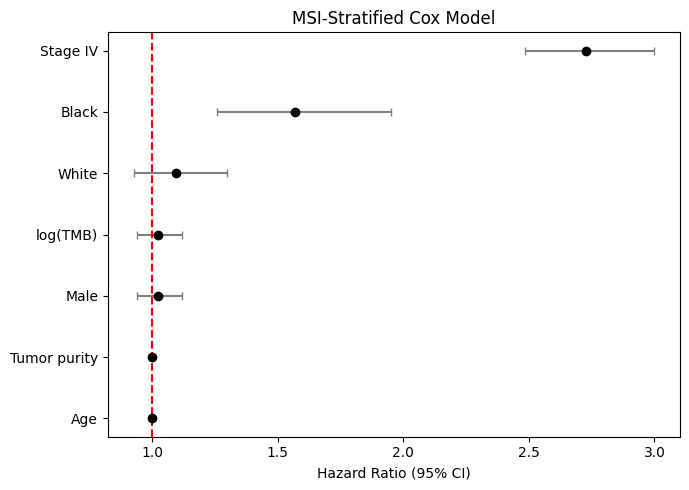

In [27]:
summary = cph_strata_msi.summary.copy()

summary["HR"] = summary["exp(coef)"]
summary["CI_lower"] = summary["exp(coef) lower 95%"]
summary["CI_upper"] = summary["exp(coef) upper 95%"]

summary = summary.reset_index()

if "covariate" in summary.columns:
    summary = summary.rename(columns={"covariate": "variable"})
else:
    summary = summary.rename(columns={"index": "variable"})

keep_vars = [
    "log_TMB",
    "age",
    "tumor_purity",
    "sex_Male",
    "Race_model_Black Or African American",
    "Race_model_White",
    "stage4_bin_Stage IV"
]

summary = summary[summary["variable"].isin(keep_vars)].copy()
summary = summary.sort_values("HR")

label_map = {
    "log_TMB": "log(TMB)",
    "age": "Age",
    "tumor_purity": "Tumor purity",
    "sex_Male": "Male",
    "Race_model_Black Or African American": "Black",
    "Race_model_White": "White",
    "stage4_bin_Stage IV": "Stage IV"
}

summary["label"] = summary["variable"].map(label_map)

y_pos = np.arange(len(summary))

plt.figure(figsize=(7,5))

plt.errorbar(
    summary["HR"],
    y_pos,
    xerr=[
        summary["HR"] - summary["CI_lower"],
        summary["CI_upper"] - summary["HR"]
    ],
    fmt="o",
    color="black",
    ecolor="gray",
    capsize=3
)

plt.axvline(x=1, linestyle="--", color="red")

plt.yticks(y_pos, summary["label"])
plt.xlabel("Hazard Ratio (95% CI)")
plt.title("MSI-Stratified Cox Model")

plt.tight_layout()
plt.show()

In [28]:
#add interaction term
cox_int_df = cox_df[[
    "OS_months",
    "event",
    "log_TMB",
    "age",
    "tumor_purity",
    "sex",
    "Race_model",
    "MSI_final",
    "stage4_bin"
]].copy()

cox_int_df["stage4_bin_num"] = (
    cox_int_df["stage4_bin"] == "Stage IV"
).astype(int)

cox_int_df["MSI_MSS_num"] = (
    cox_int_df["MSI_final"] == "MSS"
).astype(int)

cox_int_df["TMB_stage_interaction"] = (
    cox_int_df["log_TMB"] * cox_int_df["stage4_bin_num"]
)

cox_int_df["TMB_MSI_interaction"] = (
    cox_int_df["log_TMB"] * cox_int_df["MSI_MSS_num"]
)

cox_int_df = pd.get_dummies(
    cox_int_df,
    columns=["sex", "Race_model"],
    drop_first=True
)

cox_int_df = cox_int_df.drop(columns=["stage4_bin", "MSI_final"])

cph_int = CoxPHFitter()

cph_int.fit(
    cox_int_df,
    duration_col="OS_months",
    event_col="event"
)

cph_int.print_summary()

<lifelines.CoxPHFitter: fitted with 5019 total observations, 3019 right-censored observations>
             duration col = 'OS_months'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 5019
number of events observed = 2000
   partial log-likelihood = -15422.29
         time fit was run = 2026-04-28 01:18:17 UTC

---
                                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                             
log_TMB                              -0.39      0.68      0.19           -0.76           -0.02                0.47                0.98
age                                  -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
tumor_purity                          0.00      1.00      0.00           -0.00            0.00                1.00                1.00
stage4_bin_num                        0.64      1.89      0.15            0.35            0.93                1.42                2.53
MSI_MSS_num                          -0.58      0.56      0.75           -2.04            0.88                0.13                2.42
TMB_stage_interaction                 0.18      1.20      0.07            0.05            0.32                1.05                1.38
TMB_MSI_interaction                   0.32      1.38      0.19           -0.05            0.69                0.95                1.99
sex_Male                              0.02      1.02      0.05           -0.06            0.11                0.94                1.12
Race_model_Black Or African American  0.45      1.56      0.11            0.23            0.67                1.26                1.95
Race_model_Other                      0.05      1.05      0.15           -0.25            0.34                0.78                1.41
Race_model_White                      0.10      1.10      0.09           -0.07            0.26                0.93                1.30

                                      cmp to     z      p  -log2(p)
covariate                                                          
log_TMB                                 0.00 -2.07   0.04      4.69
age                                     0.00 -0.03   0.98      0.03
tumor_purity                            0.00  0.43   0.66      0.59
stage4_bin_num                          0.00  4.31 <0.005     15.92
MSI_MSS_num                             0.00 -0.77   0.44      1.19
TMB_stage_interaction                   0.00  2.63   0.01      6.88
TMB_MSI_interaction                     0.00  1.69   0.09      3.45
sex_Male                                0.00  0.53   0.60      0.74
Race_model_Black Or African American    0.00  3.99 <0.005     13.90
Race_model_Other                        0.00  0.33   0.74      0.43
Race_model_White                        0.00  1.11   0.27      1.91
---
Concordance = 0.66
Partial AIC = 30866.58
log-likelihood ratio test = 656.90 on 11 df
-log2(p) of ll-ratio test = 441.93

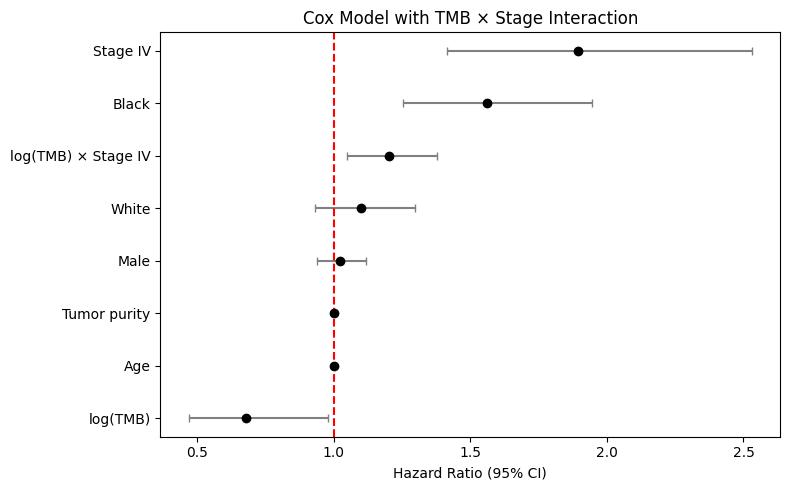

In [29]:
summary = cph_int.summary.copy()

summary["HR"] = summary["exp(coef)"]
summary["CI_lower"] = summary["exp(coef) lower 95%"]
summary["CI_upper"] = summary["exp(coef) upper 95%"]

summary = summary.reset_index()

if "covariate" in summary.columns:
    summary = summary.rename(columns={"covariate": "variable"})
else:
    summary = summary.rename(columns={"index": "variable"})

keep_vars = [
    "log_TMB",
    "stage4_bin_num",
    "TMB_stage_interaction",
    "MSI_final_MSS",
    "age",
    "tumor_purity",
    "sex_Male",
    "Race_model_Black Or African American",
    "Race_model_White"
]

summary = summary[summary["variable"].isin(keep_vars)].copy()

label_map = {
    "log_TMB": "log(TMB)",
    "stage4_bin_num": "Stage IV",
    "TMB_stage_interaction": "log(TMB) × Stage IV",
    "MSI_final_MSS": "MSS (vs MSI-High)",
    "age": "Age",
    "tumor_purity": "Tumor purity",
    "sex_Male": "Male",
    "Race_model_Black Or African American": "Black",
    "Race_model_White": "White"
}

summary["label"] = summary["variable"].map(label_map)

summary = summary.sort_values("HR")

y_pos = np.arange(len(summary))

plt.figure(figsize=(8,5))

plt.errorbar(
    summary["HR"],
    y_pos,
    xerr=[
        summary["HR"] - summary["CI_lower"],
        summary["CI_upper"] - summary["HR"]
    ],
    fmt="o",
    color="black",
    ecolor="gray",
    capsize=3
)

plt.axvline(x=1, linestyle="--", color="red")

plt.yticks(y_pos, summary["label"])
plt.xlabel("Hazard Ratio (95% CI)")
plt.title("Cox Model with TMB × Stage Interaction")

plt.tight_layout()
plt.show()

In [30]:
cox_q_df = cox_df[[
    "OS_months",
    "event",
    "TMB_quartile",
    "age",
    "tumor_purity",
    "sex",
    "Race_model",
    "MSI_final",
    "stage4_bin"
]].copy()

cox_q_df = pd.get_dummies(
    cox_q_df,
    columns=["TMB_quartile", "sex", "Race_model", "MSI_final", "stage4_bin"],
    drop_first=True
)

cph_q = CoxPHFitter()

cph_q.fit(
    cox_q_df,
    duration_col="OS_months",
    event_col="event"
)

cph_q.print_summary()

<lifelines.CoxPHFitter: fitted with 5019 total observations, 3019 right-censored observations>
             duration col = 'OS_months'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 5019
number of events observed = 2000
   partial log-likelihood = -15421.88
         time fit was run = 2026-04-28 01:18:17 UTC

---
                                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                             
age                                  -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
tumor_purity                          0.00      1.00      0.00           -0.00            0.00                1.00                1.00
TMB_quartile_Q2                       0.03      1.03      0.06           -0.09            0.15                0.91                1.16
TMB_quartile_Q3                       0.12      1.13      0.06            0.00            0.24                1.00                1.27
TMB_quartile_Q4                       0.21      1.24      0.07            0.07            0.36                1.07                1.43
sex_Male                              0.03      1.03      0.05           -0.06            0.12                0.94                1.13
Race_model_Black Or African American  0.44      1.55      0.11            0.22            0.65                1.24                1.93
Race_model_Other                      0.04      1.04      0.15           -0.25            0.33                0.78                1.40
Race_model_White                      0.09      1.09      0.09           -0.08            0.25                0.92                1.29
MSI_final_MSS                         0.87      2.39      0.12            0.63            1.11                1.89                3.02
stage4_bin_Stage IV                   1.00      2.73      0.05            0.91            1.10                2.48                3.00

                                      cmp to     z      p  -log2(p)
covariate                                                          
age                                     0.00 -0.37   0.71      0.48
tumor_purity                            0.00  0.42   0.67      0.57
TMB_quartile_Q2                         0.00  0.47   0.64      0.65
TMB_quartile_Q3                         0.00  2.00   0.05      4.45
TMB_quartile_Q4                         0.00  2.95 <0.005      8.29
sex_Male                                0.00  0.65   0.51      0.96
Race_model_Black Or African American    0.00  3.89 <0.005     13.30
Race_model_Other                        0.00  0.27   0.79      0.34
Race_model_White                        0.00  1.02   0.31      1.70
MSI_final_MSS                           0.00  7.23 <0.005     40.96
stage4_bin_Stage IV                     0.00 20.92 <0.005    320.45
---
Concordance = 0.66
Partial AIC = 30865.75
log-likelihood ratio test = 657.72 on 11 df
-log2(p) of ll-ratio test = 442.51

In [31]:
spline_basis = dmatrix(
    "0 + bs(log_TMB, df=3, include_intercept=False)",
    {"log_TMB": cox_df["log_TMB"]},
    return_type="dataframe"
)

spline_basis.columns = [
    f"log_TMB_spline_{i}" for i in range(spline_basis.shape[1])
]


base_df = cox_df[[
    "OS_months", "event",
    "age",
    "tumor_purity",
    "sex",
    "Race_model",
    "stage4_bin",
    "MSI_final"
]].copy()

base_df = pd.get_dummies(
    base_df,
    columns=["sex", "Race_model", "stage4_bin", "MSI_final"],
    drop_first=True
)


model_df = pd.concat(
    [
        base_df.reset_index(drop=True),
        spline_basis.reset_index(drop=True)
    ],
    axis=1
).dropna()

# convert bool → int
for col in model_df.columns:
    if model_df[col].dtype == "bool":
        model_df[col] = model_df[col].astype(int)

# clean inf
model_df = model_df.replace([np.inf, -np.inf], np.nan).dropna()

print(model_df.shape)


cph_spline = CoxPHFitter(penalizer=1.0)

cph_spline.fit(
    model_df,
    duration_col="OS_months",
    event_col="event"
)

cph_spline.print_summary()


(5019, 13)


<lifelines.CoxPHFitter: fitted with 5019 total observations, 3019 right-censored observations>
             duration col = 'OS_months'
                event col = 'event'
                penalizer = 1.0
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 5019
number of events observed = 2000
   partial log-likelihood = -15637.92
         time fit was run = 2026-04-28 01:18:18 UTC

---
                                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                             
age                                  -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
tumor_purity                         -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
sex_Male                              0.01      1.01      0.02           -0.04            0.06                0.97                1.06
Race_model_Black Or African American  0.10      1.11      0.05            0.01            0.19                1.01                1.21
Race_model_Other                     -0.01      0.99      0.07           -0.14            0.12                0.87                1.13
Race_model_White                     -0.02      0.98      0.03           -0.08            0.04                0.93                1.04
stage4_bin_Stage IV                   0.29      1.34      0.02            0.24            0.34                1.28                1.40
MSI_final_MSS                         0.15      1.16      0.04            0.07            0.23                1.07                1.26
log_TMB_spline_0                      0.44      1.55      0.16            0.12            0.75                1.12                2.13
log_TMB_spline_1                     -0.25      0.78      0.13           -0.51            0.01                0.60                1.01
log_TMB_spline_2                     -0.40      0.67      0.14           -0.66           -0.13                0.51                0.88

                                      cmp to     z      p  -log2(p)
covariate                                                          
age                                     0.00 -0.88   0.38      1.40
tumor_purity                            0.00 -0.47   0.64      0.64
sex_Male                                0.00  0.48   0.63      0.67
Race_model_Black Or African American    0.00  2.13   0.03      4.93
Race_model_Other                        0.00 -0.14   0.89      0.17
Race_model_White                        0.00 -0.56   0.57      0.80
stage4_bin_Stage IV                     0.00 12.09 <0.005    109.41
MSI_final_MSS                           0.00  3.72 <0.005     12.27
log_TMB_spline_0                        0.00  2.68   0.01      7.09
log_TMB_spline_1                        0.00 -1.89   0.06      4.10
log_TMB_spline_2                        0.00 -2.93 <0.005      8.20
---
Concordance = 0.64
Partial AIC = 31297.83
log-likelihood ratio test = 225.65 on 11 df
-log2(p) of ll-ratio test = 137.74

The analytic cohort included 5,019 CRC patients. High TMB appeared associated with better survival in unadjusted KM analysis, but log(TMB) was not significantly associated with OS in adjusted Cox or stage-stratified Cox models. The TMB × Stage IV interaction was significant, and spline/quartile analyses suggested a possible non-linear relationship.